In [97]:
import pygame
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt

In [98]:
SCREEN_WIDTH = 400
SCREEN_HEIGHT = 600
PIPE_GAP = 150
GRAVITY = 0.5
FLAP_STRENGTH = -8

In [99]:
class FlappyBirdEnv:
    def __init__(self, render_mode=True):
        self.render_mode = render_mode
        if self.render_mode:
            pygame.init()
            self.screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
            pygame.display.set_caption("Flappy Bird RL")
            self.clock = pygame.time.Clock()
        self.reset()

    def reset(self):
        self.bird_y = SCREEN_HEIGHT // 2
        self.bird_velocity = 0
        self.pipe_x = SCREEN_WIDTH
        self.pipe_height = random.randint(150, 450)
        self.done = False
        return self._get_state()

    def step(self, action):
        if action == 1:
            self.bird_velocity = FLAP_STRENGTH

        self.bird_velocity += GRAVITY
        self.bird_y += self.bird_velocity
        self.pipe_x -= 3

        reward = 0.1

        if self.pipe_x < 50:
            self.pipe_x = SCREEN_WIDTH
            self.pipe_height = random.randint(150, 450)
            reward = 1

        if (
            self.bird_y <= 0 or
            self.bird_y >= SCREEN_HEIGHT or
            (self.pipe_x < 80 and
             (self.bird_y < self.pipe_height - PIPE_GAP // 2 or
              self.bird_y > self.pipe_height + PIPE_GAP // 2))
        ):
            reward = -10
            self.done = True

        return self._get_state(), reward, self.done

    def _get_state(self):
        return np.array([
            self.bird_y / SCREEN_HEIGHT,
            self.bird_velocity / 10,
            self.pipe_x / SCREEN_WIDTH,
            (self.pipe_height - self.bird_y) / SCREEN_HEIGHT
        ], dtype=np.float32)

    def render(self):
        if not self.render_mode:
            return
        self.screen.fill((135, 206, 235))
        pygame.draw.circle(self.screen, (255, 255, 0), (50, int(self.bird_y)), 10)
        pygame.draw.rect(self.screen, (0, 255, 0),
            (self.pipe_x, 0, 50, self.pipe_height - PIPE_GAP // 2))
        pygame.draw.rect(self.screen, (0, 255, 0),
            (self.pipe_x, self.pipe_height + PIPE_GAP // 2, 50, SCREEN_HEIGHT))
        pygame.display.flip()
        self.clock.tick(60)

In [100]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [101]:
EPISODES = 300
GAMMA = 0.99
LR = 1e-3
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995
BATCH_SIZE = 64

In [102]:
env = FlappyBirdEnv(render_mode=False)

model = DQN(4, 2)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

replay_buffer = deque(maxlen=50000)

rewards_history = []
loss_history = []
epsilon_history = []
q_value_history = []

In [103]:
def train_step():
    if len(replay_buffer) < BATCH_SIZE:
        return

    batch = random.sample(replay_buffer, BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.tensor(states, dtype=torch.float32)
    actions = torch.tensor(actions).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32)
    next_states = torch.tensor(next_states, dtype=torch.float32)
    dones = torch.tensor(dones, dtype=torch.float32)

    q_values = model(states).gather(1, actions).squeeze()
    next_q = model(next_states).max(1)[0]

    target = rewards + GAMMA * next_q * (1 - dones)
    loss = loss_fn(q_values, target.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    q_value_history.append(q_values.mean().item())

In [104]:
for ep in range(EPISODES):
    state = env.reset()
    total_reward = 0
    done = False

    while not done:
        if random.random() < EPSILON:
            action = random.randint(0, 1)
        else:
            with torch.no_grad():
                action = torch.argmax(model(torch.tensor(state))).item()

        next_state, reward, done = env.step(action)

        replay_buffer.append((state, action, reward, next_state, done))
        train_step()

        state = next_state
        total_reward += reward

    rewards_history.append(total_reward)
    epsilon_history.append(EPSILON)
    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

    print(f"Episode {ep+1}, Reward={total_reward:.2f}")

Episode 1, Reward=-5.80
Episode 2, Reward=-5.60
Episode 3, Reward=-5.90
Episode 4, Reward=-5.50
Episode 5, Reward=-5.60
Episode 6, Reward=-5.80
Episode 7, Reward=-5.60
Episode 8, Reward=-5.70
Episode 9, Reward=-5.50
Episode 10, Reward=-5.80
Episode 11, Reward=-5.80
Episode 12, Reward=-5.80
Episode 13, Reward=-5.60
Episode 14, Reward=-5.10
Episode 15, Reward=-5.60
Episode 16, Reward=-5.50
Episode 17, Reward=-5.90
Episode 18, Reward=-5.80
Episode 19, Reward=-5.50
Episode 20, Reward=-5.70
Episode 21, Reward=-5.40
Episode 22, Reward=-5.50
Episode 23, Reward=-5.50
Episode 24, Reward=-5.80
Episode 25, Reward=-5.80
Episode 26, Reward=-4.90
Episode 27, Reward=-5.60
Episode 28, Reward=-5.50
Episode 29, Reward=-5.50
Episode 30, Reward=-5.80
Episode 31, Reward=-5.60
Episode 32, Reward=-5.40
Episode 33, Reward=-5.70
Episode 34, Reward=-5.80
Episode 35, Reward=-5.60
Episode 36, Reward=-5.50
Episode 37, Reward=-5.50
Episode 38, Reward=-5.50
Episode 39, Reward=-5.70
Episode 40, Reward=-5.30
Episode 4

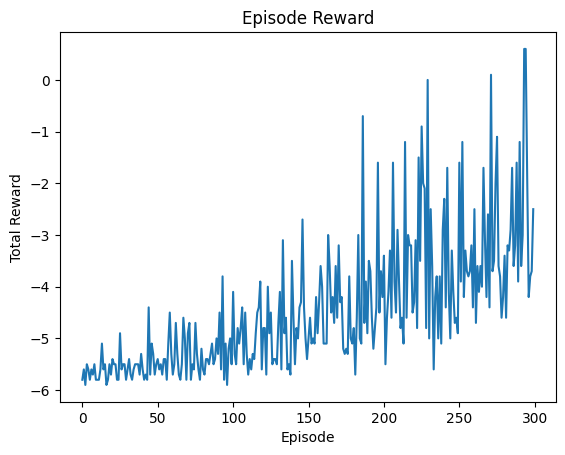

In [105]:
plt.plot(rewards_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Episode Reward")
plt.savefig("reward_curve.png")
plt.show()

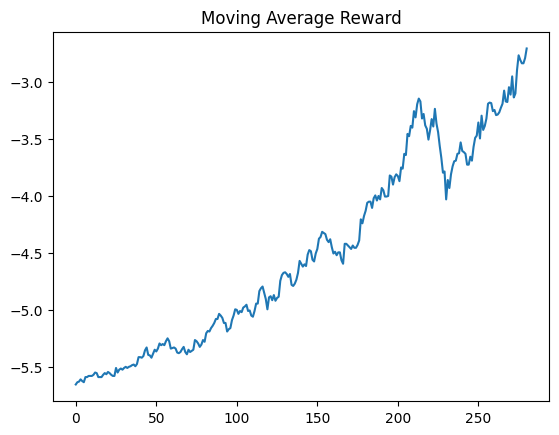

In [106]:
window = 20
moving_avg = np.convolve(rewards_history, np.ones(window)/window, mode="valid")

plt.plot(moving_avg)
plt.title("Moving Average Reward")
plt.savefig("moving_avg_reward.png")
plt.show()

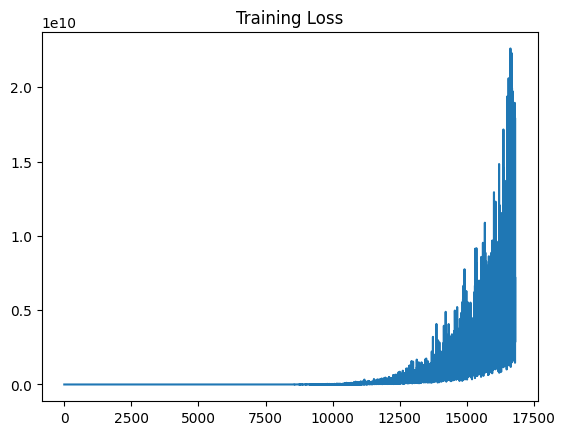

In [107]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.savefig("loss_curve.png")
plt.show()

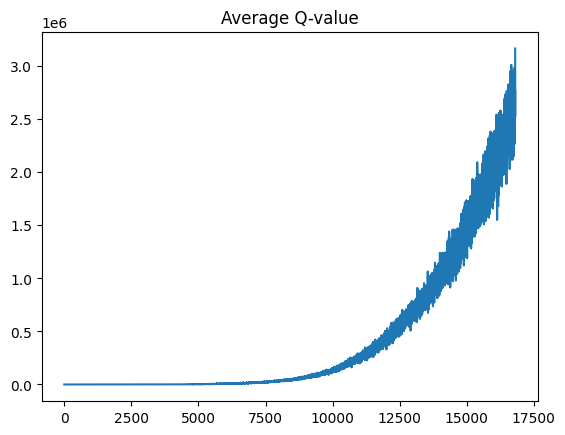

In [108]:
plt.plot(q_value_history)
plt.title("Average Q-value")
plt.savefig("q_value_curve.png")
plt.show()

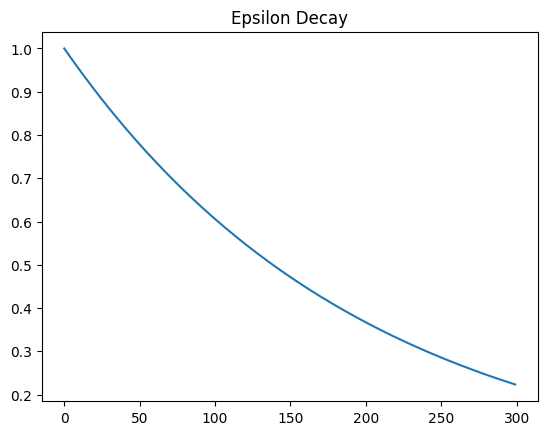

In [109]:
plt.plot(epsilon_history)
plt.title("Epsilon Decay")
plt.savefig("epsilon_decay.png")
plt.show()

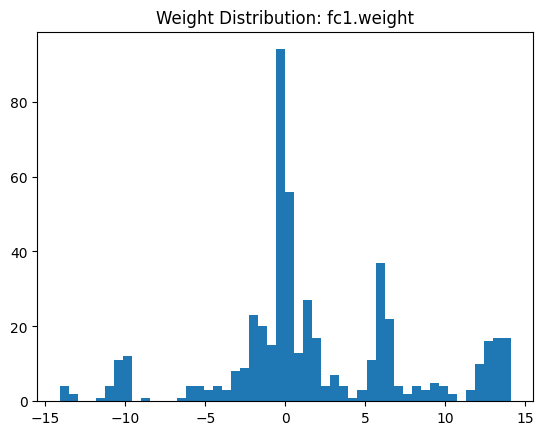

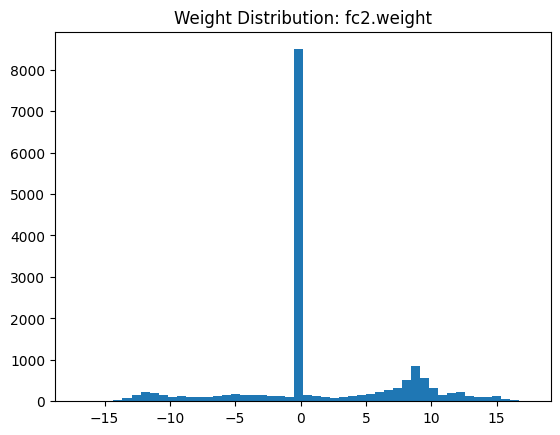

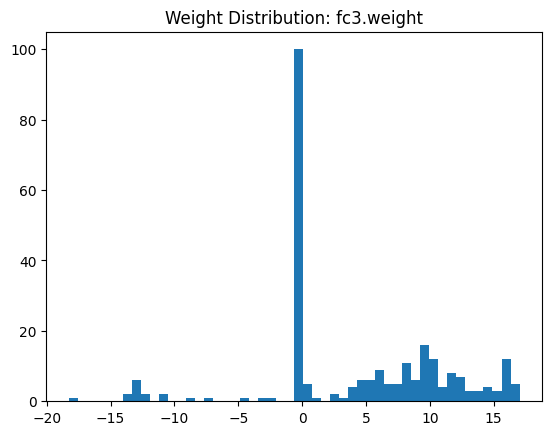

In [110]:
for name, param in model.named_parameters():
    if "weight" in name:
        plt.hist(param.detach().numpy().flatten(), bins=50)
        plt.title(f"Weight Distribution: {name}")
        plt.savefig(f"{name}_weights.png")
        plt.show()

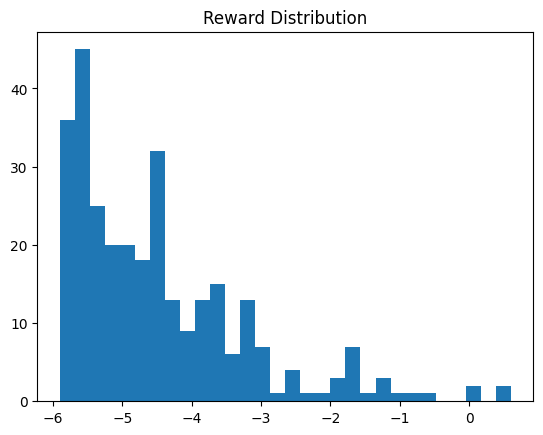

In [111]:
plt.hist(rewards_history, bins=30)
plt.title("Reward Distribution")
plt.savefig("reward_distribution.png")
plt.show()